# Workflow
1. [Data Import](#data-import)
2. [Modeling](#modeling)
3. [Presentation (Streamlit)]()

# Data Import
Original data is in JSON format.
- [ ] Explain why JSON (+)Save objects (-)manually create CSV
- [ ] Use of Numpy
- [ ] 

## Data exported from Lumeria
1. Player Position
2. Events
3. Map information (build placements)

In [2]:
{
   "saveDateTime": "2026-07-26 20:11:07",
   "playerId": "id_001",
   "playerSaveObjectList": [
      {
         "gametimer": 5.528238773345947,
         "position": {
            "x": 90.0,
            "y": 0.0,
            "z": 60.0
         },
         "rotation": {
            "x": 0.0,
            "y": 46.83423614501953,
            "z": 0.0
         }
      },
      {
         "gametimer": 6.530888080596924,
         "position": {
            "x": 90.0,
            "y": 0.0,
            "z": 60.0
         },
         "rotation": {
            "x": 0.0,
            "y": 107.00001525878906,
            "z": 0.0
         }
      }
   ]
}

{'saveDateTime': '2026-07-26 20:11:07',
 'playerId': 'id_001',
 'playerSaveObjectList': [{'gametimer': 5.528238773345947,
   'position': {'x': 90.0, 'y': 0.0, 'z': 60.0},
   'rotation': {'x': 0.0, 'y': 46.83423614501953, 'z': 0.0}},
  {'gametimer': 6.530888080596924,
   'position': {'x': 90.0, 'y': 0.0, 'z': 60.0},
   'rotation': {'x': 0.0, 'y': 107.00001525878906, 'z': 0.0}}]}

## Import player Position

In [3]:
# FIRST TRY - discarted
import pandas as pd


FILENAME = "../data/savefile_01_pos_rot.json"

# with open (FILENAME, mode="r") as file:
#    df = pd.DataFrame(file)
df = pd.read_json(FILENAME)

print(df)

           saveDateTime playerId  \
0   2026-07-26 20:11:07   id_001   
1   2026-07-26 20:11:07   id_001   
2   2026-07-26 20:11:07   id_001   
3   2026-07-26 20:11:07   id_001   
4   2026-07-26 20:11:07   id_001   
..                  ...      ...   
61  2026-07-26 20:11:07   id_001   
62  2026-07-26 20:11:07   id_001   
63  2026-07-26 20:11:07   id_001   
64  2026-07-26 20:11:07   id_001   
65  2026-07-26 20:11:07   id_001   

                                 playerSaveObjectList  
0   {'gametimer': 5.528238773345947, 'position': {...  
1   {'gametimer': 6.530888080596924, 'position': {...  
2   {'gametimer': 7.531301021575928, 'position': {...  
3   {'gametimer': 8.531609535217285, 'position': {...  
4   {'gametimer': 9.531744003295898, 'position': {...  
..                                                ...  
61  {'gametimer': 66.77377319335938, 'position': {...  
62  {'gametimer': 67.78170013427734, 'position': {...  
63  {'gametimer': 68.78193664550781, 'position': {...  
64  {'g

In [4]:
import json
import pandas as pd
import datetime as dt

FILENAME = "../data/savefile_01_pos_rot.json"
 
# 1. Load the raw JSON
with open(FILENAME, mode="r") as file:
    json_data = json.load(file)

# 2. Extract top-level metadata
player_id: str = json_data["playerId"]
save_time: dt.datetime = dt.datetime.strptime(json_data["saveDateTime"], "%Y-%m-%d %H:%M:%S")

# 3. Build rows from the list, reshaping position/rotation into tuples
rows = []
for entry in json_data["playerSaveObjectList"]:
    rows.append({
        "time":      entry["gametimer"],
        "position":  (entry["position"]["x"], entry["position"]["y"], entry["position"]["z"]),
        "rotation":  (entry["rotation"]["x"], entry["rotation"]["y"], entry["rotation"]["z"]),
        "playerId":  player_id,
        "saveTime":  save_time,
    })

# 4. Create the DataFrame
df = pd.DataFrame(rows)

print(df.head())
print("-----------")
print(df.dtypes)

       time           position                        rotation playerId  \
0  5.528239  (90.0, 0.0, 60.0)   (0.0, 46.83423614501953, 0.0)   id_001   
1  6.530888  (90.0, 0.0, 60.0)  (0.0, 107.00001525878906, 0.0)   id_001   
2  7.531301  (90.0, 0.0, 60.0)   (0.0, 95.61361694335938, 0.0)   id_001   
3  8.531610  (90.0, 0.0, 60.0)   (0.0, 95.61361694335938, 0.0)   id_001   
4  9.531744  (90.0, 0.0, 60.0)   (0.0, 87.09896087646484, 0.0)   id_001   

             saveTime  
0 2026-07-26 20:11:07  
1 2026-07-26 20:11:07  
2 2026-07-26 20:11:07  
3 2026-07-26 20:11:07  
4 2026-07-26 20:11:07  
-----------
time               float64
position            object
rotation            object
playerId               str
saveTime    datetime64[us]
dtype: object


# Modeling

## Plot the player's position over time

### Plot position

[90.0, 90.0, 90.0, 90.0, 90.0, 90.0, 90.0, 89.79219818115234, 89.01451110839844, 89.1740493774414, 89.1539306640625, 89.23359680175781, 89.23359680175781, 89.23359680175781, 90.29725646972656, 91.54380798339844, 91.98143768310547, 92.99075317382812, 95.3897476196289, 98.26689910888672, 101.28170013427734, 104.1786880493164, 107.03135681152344, 109.98646545410156, 112.87757873535156, 115.71399688720703, 118.56256103515625, 121.56963348388672, 124.58345794677734, 127.58360290527344, 130.60678100585938, 133.60589599609375, 136.61346435546875, 139.43191528320312, 142.15440368652344, 144.55966186523438, 146.43959045410156, 147.8705291748047, 148.36276245117188, 148.79147338867188, 148.83612060546875, 148.86541748046875, 149.2828369140625, 149.43482971191406, 149.58746337890625, 149.61044311523438, 149.67214965820312, 149.6884765625, 149.7047882080078, 149.9098663330078, 150.00125122070312, 150.0737762451172, 150.1464385986328, 150.01397705078125, 149.5387725830078, 148.05519104003906, 146.1

(-15.0, 165.0)

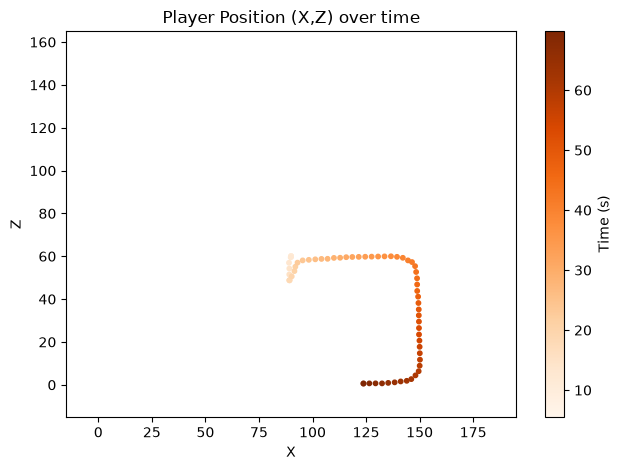

In [5]:
import matplotlib.pyplot as plt

# MAP SIZE
GRID_COLS: int = 6
GRID_ROWS: int = 5
BLOCK_SIZE: int = 30

# The extent is computed — maps pixel corners to world coordinates
map_extent = [
    -BLOCK_SIZE / 2,
    (GRID_COLS - 0) * BLOCK_SIZE + BLOCK_SIZE / 2,
    -BLOCK_SIZE / 2,
    (GRID_ROWS - 0) * BLOCK_SIZE + BLOCK_SIZE / 2,
]

x_list =  [x for (x,y,z) in df["position"]]
z_list =  [z for (x,y,z) in df["position"]]
rot_y_list = [y for (x,y,z) in df["rotation"]]
t_list: list[float] = [_ for _ in df["time"]]

print(x_list)
print(z_list)
print(t_list)
print(rot_y_list)

fig, ax = plt.subplots()

scatter = ax.scatter(x_list,z_list, c=t_list, cmap="Oranges", s=10) #  edgecolors="orange", linewidths=0.5
ax.set_title("Player Position (X,Z) over time")
ax.set_xlabel("X")
ax.set_ylabel("Z")
ax.set_aspect("equal")

plt.colorbar(scatter, ax=ax, label="Time (s)")
plt.tight_layout()

plt.xlim(map_extent[0],map_extent[1])
plt.ylim(map_extent[2], map_extent[3])

### Overlay the image
- [ ] Need to plan for map with global POIs

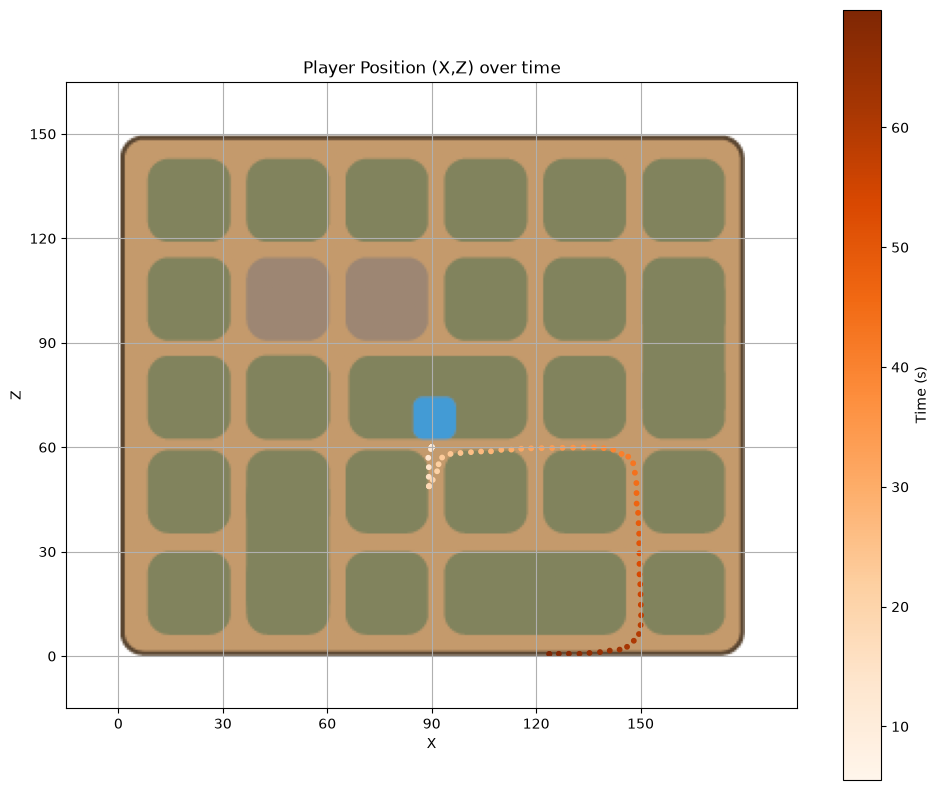

In [ ]:
import matplotlib.image as mpimg
import numpy as np

# --- Map config (change per level) ---
MAP_IMAGE = "../images/map_level1.png"

map = mpimg.imread(MAP_IMAGE)

map_x_offset = BLOCK_SIZE / 2
map_z_offset = BLOCK_SIZE / 2

map_coord = [
    -BLOCK_SIZE / 2,
    (GRID_COLS - 1) * BLOCK_SIZE + BLOCK_SIZE / 2,
    -BLOCK_SIZE / 2,
    (GRID_ROWS - 1) * BLOCK_SIZE + BLOCK_SIZE / 2,
]

map_coord[0] += map_x_offset  # left
map_coord[1] += map_x_offset  # right
map_coord[2] += map_z_offset  # bottom
map_coord[3] += map_z_offset  # top


fig2, ax2 = plt.subplots(nrows=1, ncols=1, figsize=(10, 8))

scatter = ax2.scatter(x_list,z_list, c=t_list, cmap="Oranges", s=10) #  edgecolors="orange", linewidths=0.5

ax2.imshow(map, extent=map_coord, origin="upper", aspect="equal")
ax2.set_title("Player Position (X,Z) over time")
ax2.set_xlabel("X")
ax2.set_ylabel("Z")
ax2.set_aspect("equal")

ticks = np.arange(0,map_coord[1],30)
ax2.set_xticks(ticks)
ax2.set_yticks(ticks)

plt.colorbar(scatter, ax=ax2, label="Time (s)")
plt.tight_layout()


plt.xlim(map_extent[0],map_extent[1])
plt.ylim(map_extent[2], map_extent[3])

plt.grid()

## Animate the position

### Animated movement with ipwidget

>Jupyter Widgets are interactive browser controls for Jupyter notebooks. Examples include:
>- Basic form controls like sliders, checkboxes, text inputs
>- Container controls like tabs, accordions, horizontal and vertical layout boxes, grid layouts
>- Advanced controls like maps, 2d and 3d visualizations, datagrids, and more
>
>Source: [ipywidgets documentation](https://ipywidgets.readthedocs.io/en/stable/)


interactive(children=(IntSlider(value=0, description='Frame', max=65), Output()), _dom_classes=('widget-intera…

<function __main__.update(frame)>

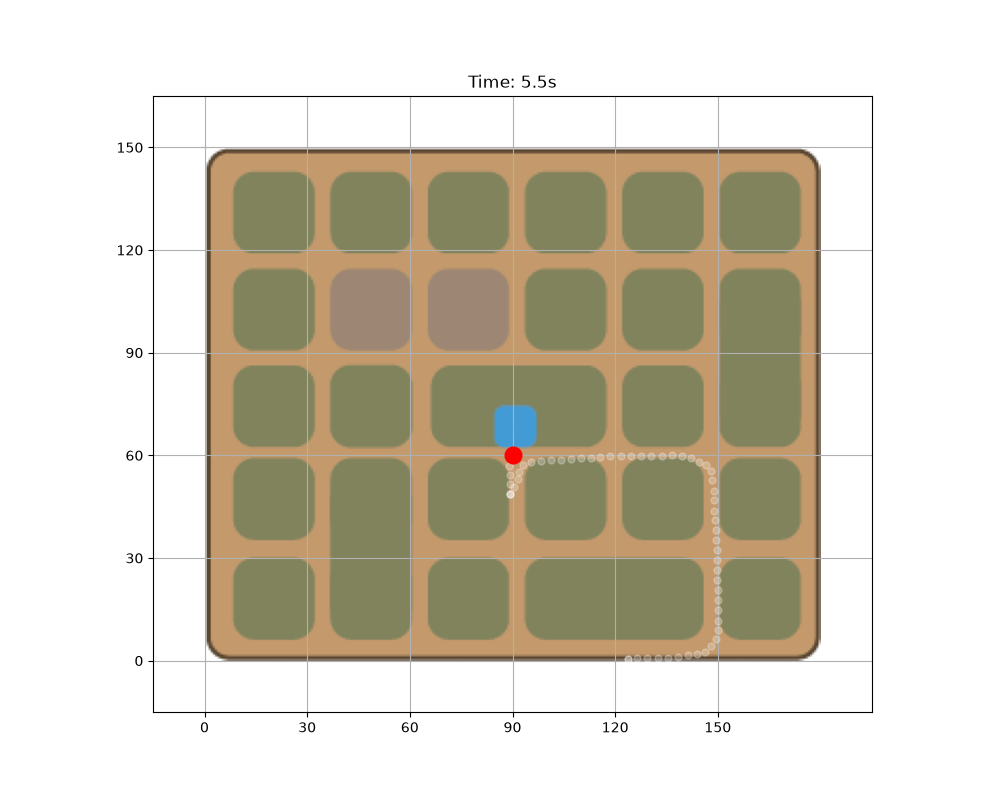

In [11]:
%matplotlib widget
import ipywidgets as widgets
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

map = mpimg.imread("../images/map_level1.png")

fig3, ax3 = plt.subplots(figsize=(10, 8))
ax3.imshow(map, extent=map_coord, origin="upper", aspect="equal")

# Plot all dots faded as a trail
trail, = ax3.plot(x_list, z_list, 'o', color='white', alpha=0.25, markersize=5)

# Active path up to current time
path, = ax3.plot([], [], '-o', color='cyan', markersize=4, linewidth=1)

# Current position marker
current, = ax3.plot([], [], 'o', color='red', markersize=12, zorder=10)

ax3.set_title("Player Position over Time")
ticks = np.arange(0,map_coord[1],30)


ax3.set_xlim(map_extent[0], map_extent[1])
ax3.set_ylim(map_extent[2], map_extent[3])
ax3.set_xticks(ticks)
ax3.set_yticks(ticks)

plt.grid()

def update(frame):
    path.set_data(x_list[:frame+1], z_list[:frame+1])
    current.set_data([x_list[frame]], [z_list[frame]])

    ax3.set_title(f"Time: {t_list[frame]:.1f}s")
    fig3.canvas.draw_idle()

# --------- WIDGET --------- #
slider = widgets.IntSlider(min=0, max=len(x_list)-1, step=1, value=0, description="Frame")

widgets.interact(update, frame=slider)


### Add play button to animation player's position

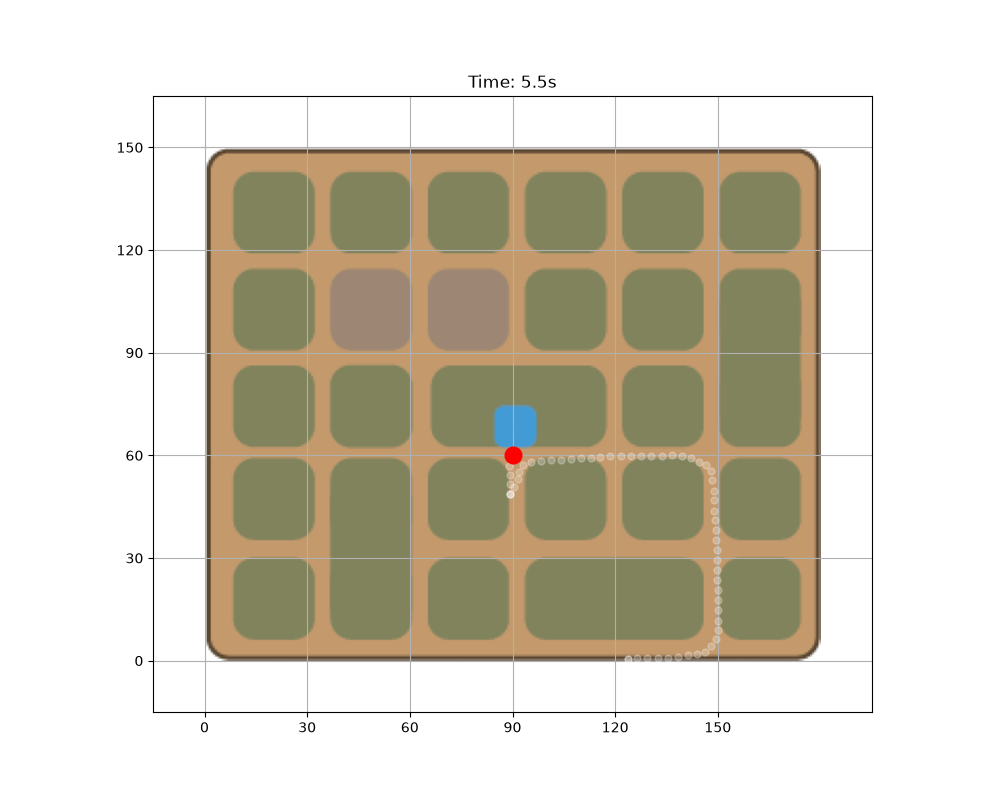

In [12]:
%matplotlib widget
import ipywidgets as widgets
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

map = mpimg.imread("../images/map_level1.png")

fig4, ax4 = plt.subplots(figsize=(10, 8))
ax4.imshow(map, extent=map_coord, origin="upper", aspect="equal")

# Plot all dots faded as a trail
trail, = ax4.plot(x_list, z_list, 'o', color='white', alpha=0.25, markersize=5)

# Active path up to current time
path, = ax4.plot([], [], '-o', color='cyan', markersize=4, linewidth=1)

# Current position marker
current, = ax4.plot([], [], 'o', color='red', markersize=12, zorder=10)

ax4.set_title("Player Position over Time")
ticks = np.arange(0,map_coord[1],30)


ax4.set_xlim(map_extent[0], map_extent[1])
ax4.set_ylim(map_extent[2], map_extent[3])
ax4.set_xticks(ticks)
ax4.set_yticks(ticks)

plt.grid()

def update(frame):
    path.set_data(x_list[:frame+1], z_list[:frame+1])
    current.set_data([x_list[frame]], [z_list[frame]])

    ax4.set_title(f"Time: {t_list[frame]:.1f}s")
    fig4.canvas.draw_idle()

# --------- WIDGET --------- #
play = widgets.Play(
    value=0,
    min=0,
    max=len(x_list)-1,
    step=1,
    interval=100,         # milliseconds between frames, 100 = 10fps
    description="Play"
)

slider = widgets.IntSlider(min=0, max=len(x_list)-1, step=1, value=0, description="Frame")

# Link them — dragging the slider or pressing play both drive the same value
widgets.jslink((play, 'value'), (slider, 'value'))

ui = widgets.HBox([play, slider])
widgets.interactive_output(update, {'frame': slider})
display(ui)


## Add player rotation (to a fixed triangle)

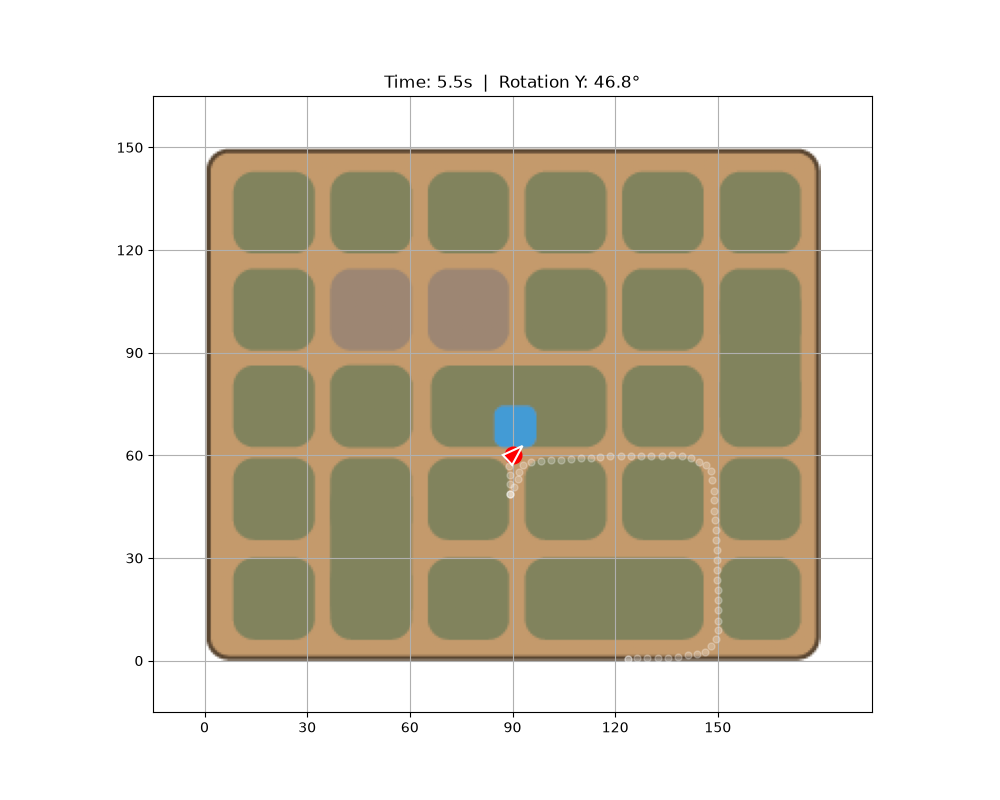

In [18]:
# Cell 2 — add triangle + redefine update + new widgets

from matplotlib.patches import Polygon

fig5, ax5 = plt.subplots(figsize=(10, 8))
ax5.imshow(map, extent=map_coord, origin="upper", aspect="equal")

# Plot all dots faded as a trail
trail, = ax5.plot(x_list, z_list, 'o', color='white', alpha=0.25, markersize=5)

# Active path up to current time
path, = ax5.plot([], [], '-o', color='cyan', markersize=4, linewidth=1)

# Current position marker
current, = ax5.plot([], [], 'o', color='red', markersize=12, zorder=10)

ax5.set_title("Player Position over Time")
ticks = np.arange(0,map_coord[1],30)


ax5.set_xlim(map_extent[0], map_extent[1])
ax5.set_ylim(map_extent[2], map_extent[3])
ax5.set_xticks(ticks)
ax5.set_yticks(ticks)

plt.grid()

SIZE = 4
base_triangle = np.array([
    [0, SIZE],
    [-SIZE/2, -SIZE/2],
    [SIZE/2, -SIZE/2],
])

CENTER_X = 90
CENTER_Z = 60

tri_patch = Polygon(base_triangle, closed=True, fc='red', ec='white', lw=1.5, zorder=11)
ax5.add_patch(tri_patch)

# Must redefine — the old update doesn't know about tri_patch
def update(frame):
    path.set_data(x_list[:frame+1], z_list[:frame+1])
    current.set_data([x_list[frame]], [z_list[frame]])

    angle = -rot_y_list[frame]
    rad = np.radians(angle)
    cos_a, sin_a = np.cos(rad), np.sin(rad)
    rotated = np.array([
        [v[0]*cos_a - v[1]*sin_a, v[0]*sin_a + v[1]*cos_a]
        for v in base_triangle
    ])
    rotated[:, 0] += CENTER_X
    rotated[:, 1] += CENTER_Z
    tri_patch.set_xy(rotated)

    ax5.set_title(f"Time: {t_list[frame]:.1f}s  |  Rotation Y: {rot_y_list[frame]:.1f}°")
    fig5.canvas.draw_idle()

# Must recreate widgets — old ones are linked to old update
play = widgets.Play(value=0, min=0, max=len(x_list)-1, step=1, interval=100)
slider = widgets.IntSlider(min=0, max=len(x_list)-1, step=1, value=0, description="Frame")
widgets.jslink((play, 'value'), (slider, 'value'))
ui = widgets.HBox([play, slider])
widgets.interactive_output(update, {'frame': slider})
display(ui)

### Move triangle's position

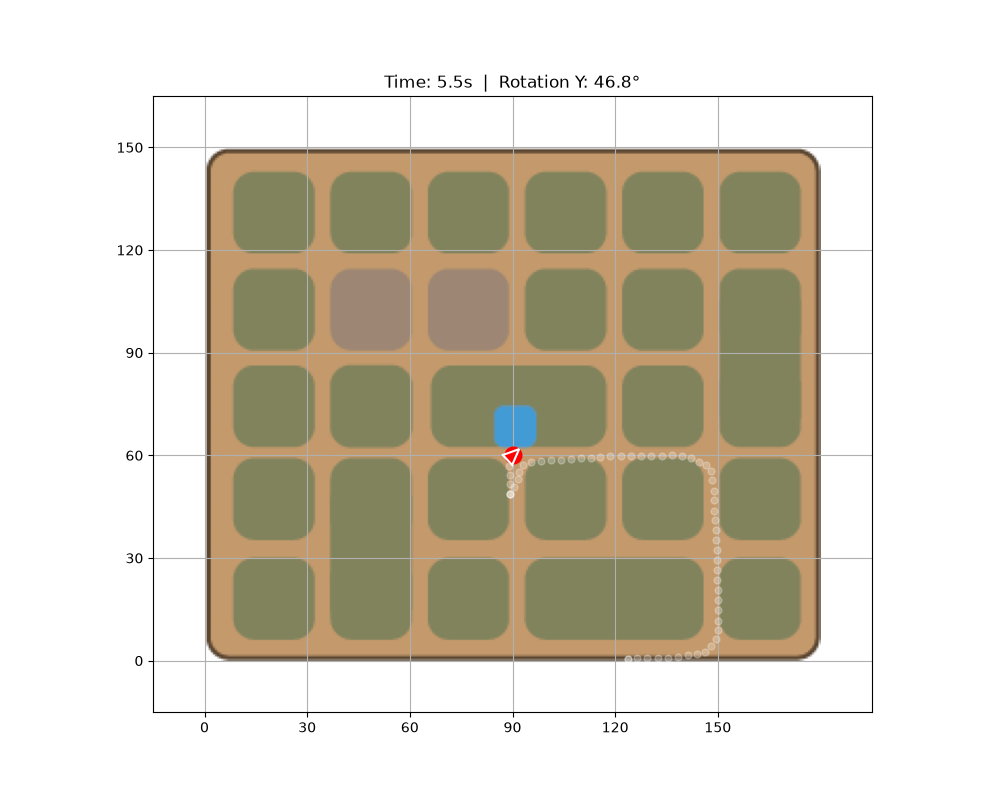

In [ ]:
# Cell 2 — add triangle + redefine update + new widgets

from matplotlib.patches import Polygon

fig6, ax6 = plt.subplots(figsize=(10, 8))
ax6.imshow(map, extent=map_coord, origin="upper", aspect="equal")

# Plot all dots faded as a trail
trail, = ax6.plot(x_list, z_list, 'o', color='white', alpha=0.25, markersize=5)

# Active path up to current time
path, = ax6.plot([], [], '-o', color='cyan', markersize=4, linewidth=1)

# Current position marker
current, = ax6.plot([], [], 'o', color='red', markersize=12, zorder=10)

ax6.set_title("Player Position over Time")
ticks = np.arange(0,map_coord[1],30)


ax6.set_xlim(map_extent[0], map_extent[1])
ax6.set_ylim(map_extent[2], map_extent[3])
ax6.set_xticks(ticks)
ax6.set_yticks(ticks)

plt.grid()

SIZE = 4
base_triangle = np.array([
    [0, SIZE/2],
    [-SIZE/2, -SIZE/2],
    [SIZE/2, -SIZE/2],
])

CENTER_X = 90
CENTER_Z = 60

tri_patch = Polygon(base_triangle, closed=True, fc='red', ec='white', lw=1.5, zorder=11)
tri_patch.set_visible(False)  # hidden until first slider move
#current marker has zorder=10, the triangle has zorder=11. Higher zorder draws on top.
#tri_patch.set_zorder(15)
ax6.add_patch(tri_patch)

# Must redefine — the old update doesn't know about tri_patch
def update(frame):
    path.set_data(x_list[:frame+1], z_list[:frame+1])
    current.set_data([x_list[frame]], [z_list[frame]])
    

    # Triangle one frame ahead
    next_frame = min(frame + 1, len(x_list) - 1)
    angle = -rot_y_list[frame]
    rad = np.radians(angle)
    cos_a, sin_a = np.cos(rad), np.sin(rad)
    rotated = np.array([
        [v[0]*cos_a - v[1]*sin_a, v[0]*sin_a + v[1]*cos_a]
        for v in base_triangle
    ])
    rotated[:, 0] += x_list[next_frame]
    rotated[:, 1] += z_list[next_frame]
    tri_patch.set_xy(rotated)
    tri_patch.set_visible(True)

    ax6.set_title(f"Time: {t_list[frame]:.1f}s  |  Rotation Y: {rot_y_list[frame]:.1f}°")
    fig6.canvas.draw_idle()

# Must recreate widgets — old ones are linked to old update
play = widgets.Play(value=0, min=0, max=len(x_list)-1, step=1, interval=100)
slider = widgets.IntSlider(min=0, max=len(x_list)-1, step=1, value=0, description="Frame")
widgets.jslink((play, 'value'), (slider, 'value'))
ui = widgets.HBox([play, slider])
widgets.interactive_output(update, {'frame': slider})
display(ui)